# Image Alignment

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## Read and Display first

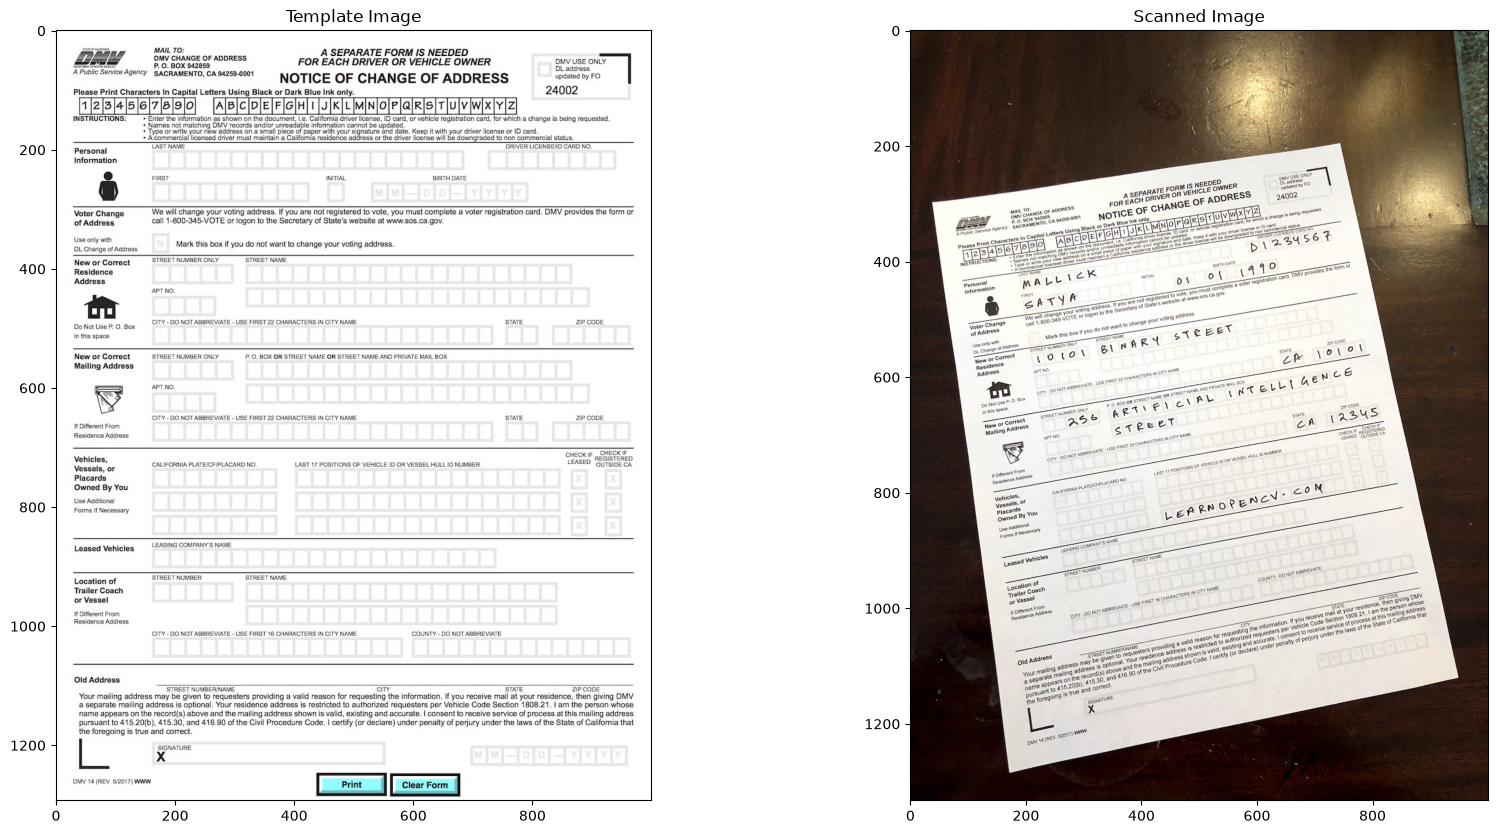

In [5]:
img_template_bgr = cv.imread('../Images/form.jpg', cv.IMREAD_COLOR)
img_template = cv.cvtColor(img_template_bgr, cv.COLOR_BGR2RGB)

img_scanned_bgr = cv.imread('../Images/scanned-form.jpg', cv.IMREAD_COLOR)
img_scanned = cv.cvtColor(img_scanned_bgr, cv.COLOR_BGR2RGB)

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1); plt.imshow(img_template); plt.title('Template Image');
plt.subplot(1, 2, 2); plt.imshow(img_scanned); plt.title('Scanned Image');
plt.show()


## Find Keypoints

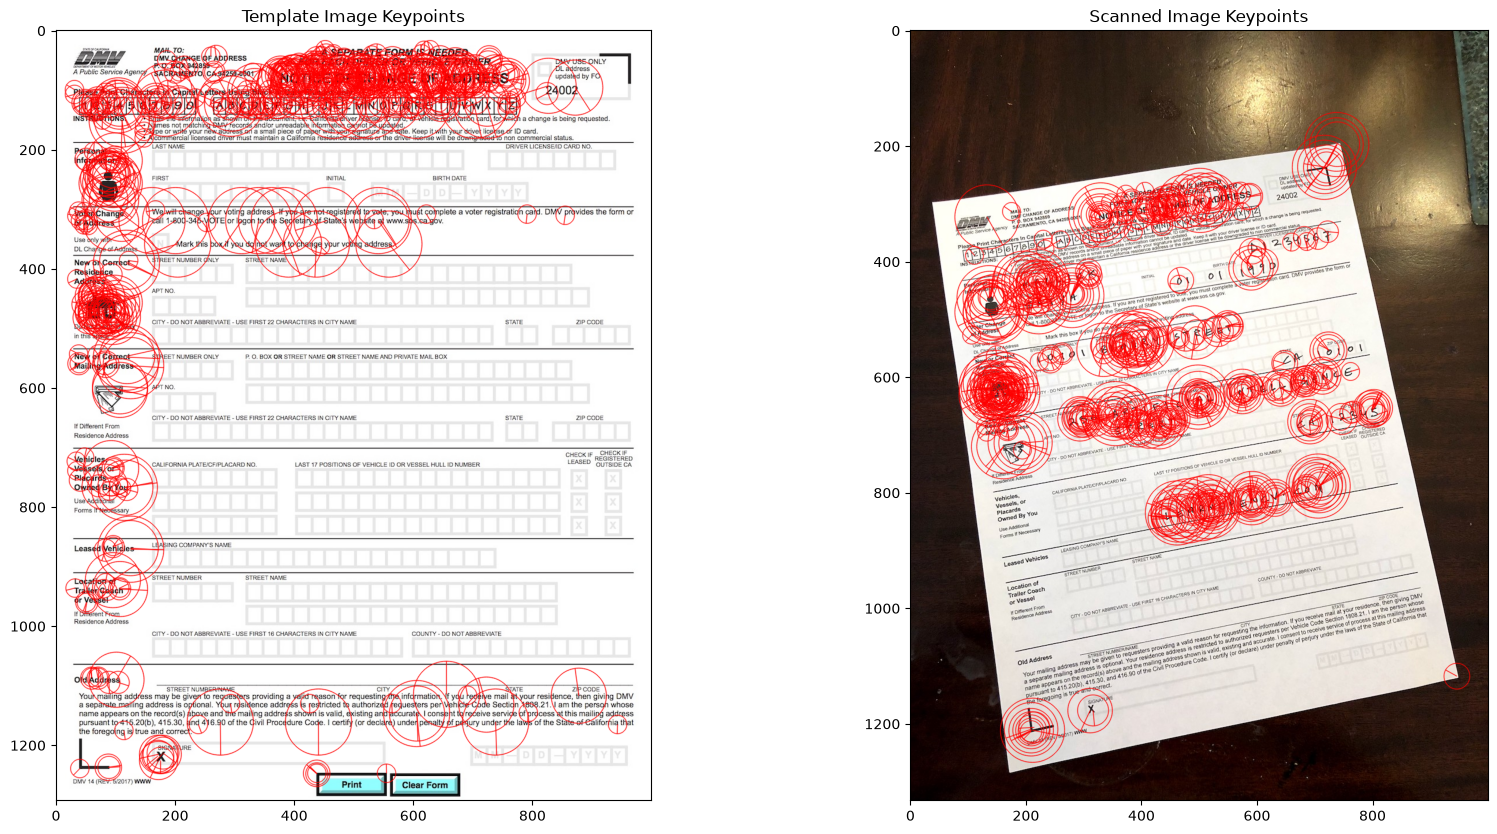

In [6]:
img_template_gray = cv.cvtColor(img_template, cv.COLOR_RGB2GRAY)
img_scanned_gray = cv.cvtColor(img_scanned, cv.COLOR_RGB2GRAY)

MAX_NUM_FEATURES = 500

# Create ORB detector as feature extractor
orb = cv.ORB_create(MAX_NUM_FEATURES)

keypoints_template, descriptors_template = orb.detectAndCompute(img_template_gray, None)
keypoints_scanned, descriptors_scanned = orb.detectAndCompute(img_scanned_gray, None)

keypoints_template_display = cv.drawKeypoints(img_template, keypoints_template, outImage = np.array([]), color=(255, 0, 0), flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
keypoints_scanned_display = cv.drawKeypoints(img_scanned, keypoints_scanned, outImage = np.array([]), color=(255, 0, 0), flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1); plt.imshow(keypoints_template_display); plt.title('Template Image Keypoints');
plt.subplot(1, 2, 2); plt.imshow(keypoints_scanned_display); plt.title('Scanned Image Keypoints');
plt.show()  

## Matching Keypoints

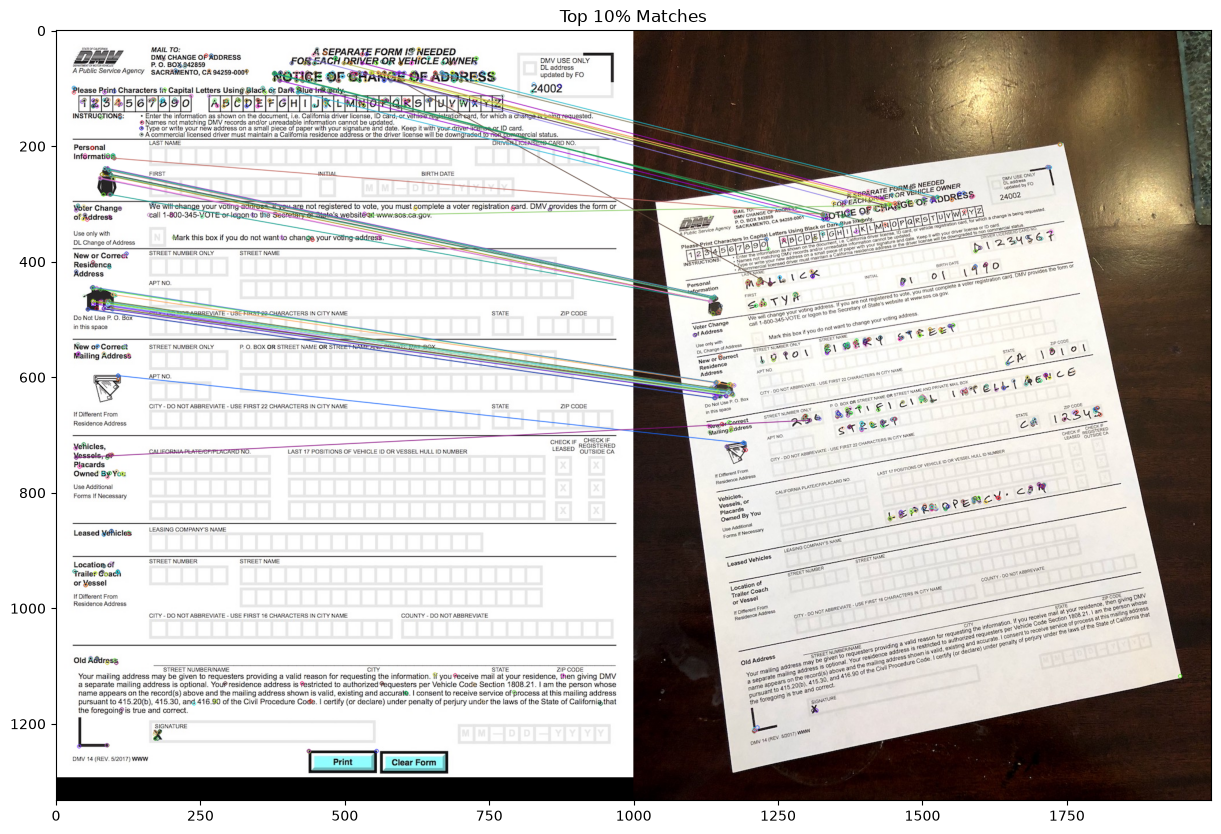

In [ ]:
matcher = cv.DescriptorMatcher_create(cv.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = matcher.match(descriptors_template, descriptors_scanned, None)

matches = np.asarray(matches) # Might be a versioning problem but I had to convert the matches from a tuple to a np.array to sort.
matches = sorted(matches, key=lambda x: x.distance, reverse=False) # Had to use sorted() instead of .sort() because the latter didn't expect key as a parameter. I think this is a versioning problem as well.

# Limit to top 10% of matches
num_good_matches = int(len(matches) * 0.1)
matches = matches[:num_good_matches]

# Visualization of matches
img_matches = cv.drawMatches(img_template, keypoints_template, img_scanned, keypoints_scanned, matches, None)

plt.figure(figsize=(40, 10))
plt.imshow(img_matches); plt.title('Top 10% Matches');

## Find Homography

In [14]:
# Changing format of matches for homography function
points_template = np.zeros((len(matches), 2), dtype=np.float32)
points_scanned = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points_template[i, :] = keypoints_template[match.queryIdx].pt
    points_scanned[i, :] = keypoints_scanned[match.trainIdx].pt

homography_codex, mask = cv.findHomography(points_scanned, points_template, cv.RANSAC)

## Warp Image according to homography

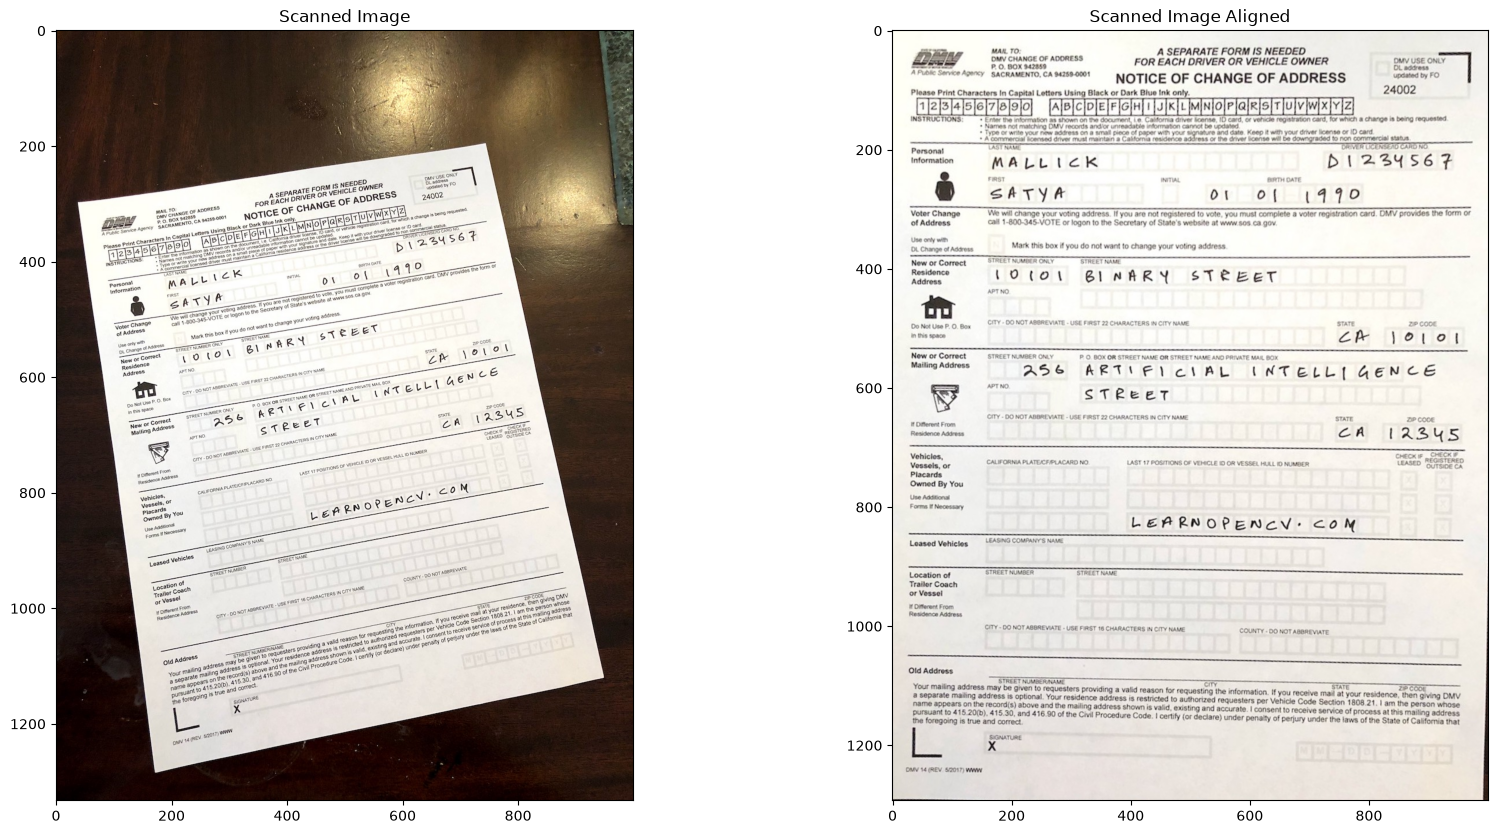

In [15]:
height, width, channels = img_template.shape
img_scanned_aligned = cv.warpPerspective(img_scanned, homography_codex, (width, height))

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1); plt.imshow(img_scanned); plt.title('Scanned Image');
plt.subplot(1, 2, 2); plt.imshow(img_scanned_aligned); plt.title('Scanned Image Aligned');
plt.show()  